Saved quantization_comparison.pdf and .png


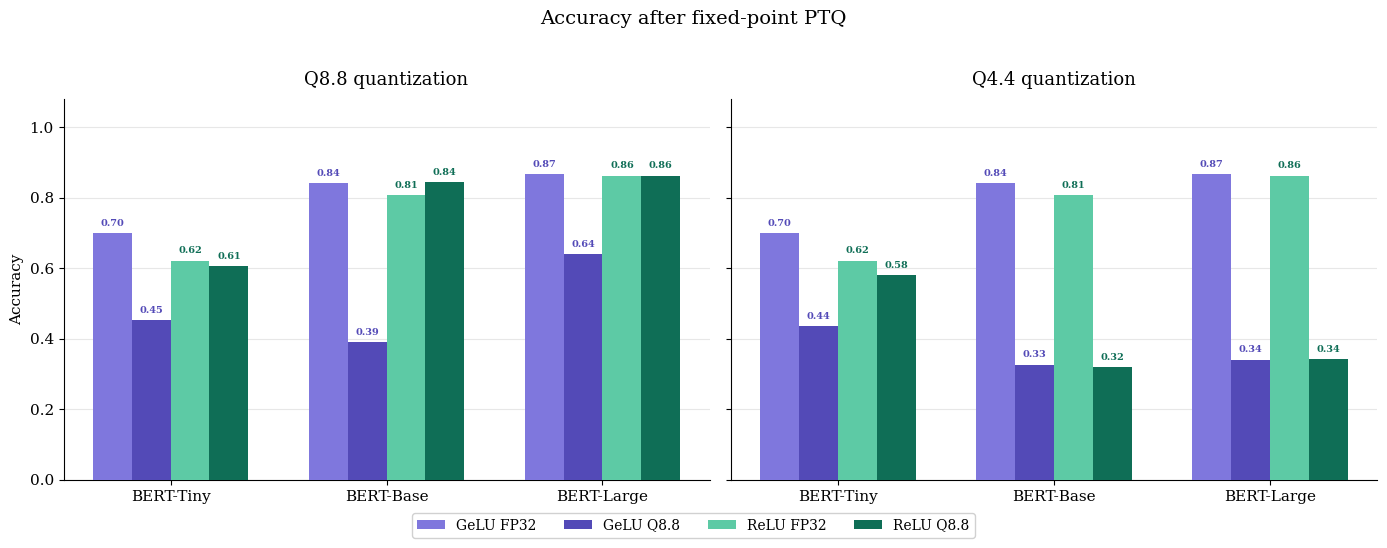

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

models = ['BERT-Tiny', 'BERT-Base', 'BERT-Large']

gelu_fp32 = [0.6990, 0.8420, 0.8665]
relu_fp32 = [0.6215, 0.8062, 0.8626]

gelu_q88 = [0.4526, 0.3902, 0.6389]
relu_q88 = [0.6059, 0.8436, 0.8620]

gelu_q44 = [0.4364, 0.3264, 0.3406]
relu_q44 = [0.5810, 0.3199, 0.3420]

x = np.arange(len(models))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

colors = {
    'gelu_fp32': '#7F77DD',
    'gelu_q':    '#534AB7',
    'relu_fp32': '#5DCAA5',
    'relu_q':    '#0F6E56',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, q_label, gelu_q, relu_q in [
    (ax1, 'Q8.8', gelu_q88, relu_q88),
    (ax2, 'Q4.4', gelu_q44, relu_q44),
]:
    ax.bar(x + offsets[0]*width, gelu_fp32, width, label='GeLU FP32', color=colors['gelu_fp32'], zorder=3)
    ax.bar(x + offsets[1]*width, gelu_q, width, label=f'GeLU {q_label}', color=colors['gelu_q'], zorder=3)
    ax.bar(x + offsets[2]*width, relu_fp32, width, label='ReLU FP32', color=colors['relu_fp32'], zorder=3)
    ax.bar(x + offsets[3]*width, relu_q, width, label=f'ReLU {q_label}', color=colors['relu_q'], zorder=3)

    for i in range(len(models)):
        for j, (vals, col) in enumerate(zip(
            [gelu_fp32, gelu_q, relu_fp32, relu_q],
            [colors['gelu_q'], colors['gelu_q'], colors['relu_q'], colors['relu_q']]
        )):
            val = vals[i]
            bx = x[i] + offsets[j]*width
            ax.text(bx, val + 0.015, f'{val:.2f}', ha='center', va='bottom',
                    fontsize=7, color=col, fontweight='bold')

    ax.set_title(f'{q_label} quantization', fontsize=13, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', alpha=0.3, zorder=1)

ax1.set_ylabel('Accuracy')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), framealpha=0.9)

fig.suptitle('Accuracy after fixed-point PTQ', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('quantization_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('quantization_comparison.png', bbox_inches='tight', dpi=300)
print("Saved quantization_comparison.pdf and .png")